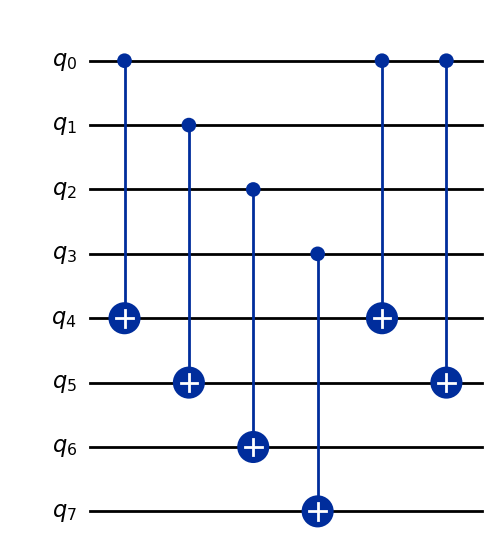

x (binary) | x ⊕ s (binary) | f(x) | f(x ⊕ s) | Match?
------------------------------------------------------------
0000      | 0011      | 0000 | 0000 | Yes
0001      | 0010      | 0010 | 0010 | Yes
0010      | 0001      | 0010 | 0010 | Yes
0011      | 0000      | 0000 | 0000 | Yes
0100      | 0111      | 0100 | 0100 | Yes
0101      | 0110      | 0110 | 0110 | Yes
0110      | 0101      | 0110 | 0110 | Yes
0111      | 0100      | 0100 | 0100 | Yes
1000      | 1011      | 1000 | 1000 | Yes
1001      | 1010      | 1010 | 1010 | Yes
1010      | 1001      | 1010 | 1010 | Yes
1011      | 1000      | 1000 | 1000 | Yes
1100      | 1111      | 1100 | 1100 | Yes
1101      | 1110      | 1110 | 1110 | Yes
1110      | 1101      | 1110 | 1110 | Yes
1111      | 1100      | 1100 | 1100 | Yes


In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# Parameters

bs = '0011'  # Secret string s in binary
n = len(bs)
s_int = int(bs, 2)  # Convert s to integer (1001 binary = 9 decimal)

# Define the Simon oracle (your provided code)
simon_oracle1 = QuantumCircuit(2*n)
for i in range(n):
    simon_oracle1.cx(i, n+i)
k = 0
for i in range(n-1, -1, -1):
    if bs[i] == '1':
        m = n
        for j in range(n-1, -1, -1):
            if bs[j] == '1':
                simon_oracle1.cx(k, m)
            m += 1
        break
    k += 1

display(simon_oracle1.draw('mpl'))

# Initialize the simulator
simulator = AerSimulator()

# Function to compute f(x) for a given input x
def compute_fx(x, oracle, n):
    # Create a circuit with 2n qubits and n classical bits for measurement
    qc = QuantumCircuit(2*n, n)
    # Set the input register (qubits 0 to n-1) to |x>
    # Qubit 0 is the least significant bit
    for i in range(n):
        if (x >> i) & 1:  # Check each bit of x
            qc.x(i)
    # Apply the oracle
    qc.append(oracle, range(2*n))
    # Measure the output register (qubits n to 2n-1) into classical bits 0 to n-1
    qc.measure(range(n, 2*n), range(n))
    # Transpile and run the circuit
    compiled_circuit = transpile(qc, simulator)
    job = simulator.run(compiled_circuit, shots=1)  # Single shot since it's deterministic
    result = job.result()
    counts = result.get_counts()
    # Extract the output (there will be only one key since it's deterministic)
    fx = list(counts.keys())[0]
    return fx

# Compute f(x) for all possible inputs x and store in a dictionary
fx_dict = {}
for x in range(2**n):
    fx = compute_fx(x, simon_oracle1, n)
    fx_dict[x] = fx

# Print the truth table
print("x (binary) | x ⊕ s (binary) | f(x) | f(x ⊕ s) | Match?")
print("-" * 60)
for x in range(2**n):
    # Convert x to 4-bit binary string
    x_bin = format(x, f'0{n}b')
    # Compute x ⊕ s
    x_xor_s = x ^ s_int
    # Convert x ⊕ s to 4-bit binary string
    x_xor_s_bin = format(x_xor_s, f'0{n}b')
    # Get f(x) and f(x ⊕ s) from the dictionary
    fx = fx_dict[x]
    fx_xor_s = fx_dict[x_xor_s]
    # Check if f(x) equals f(x ⊕ s)
    match = "Yes" if fx == fx_xor_s else "No"
    # Print the row
    print(f"{x_bin}      | {x_xor_s_bin}      | {fx} | {fx_xor_s} | {match}")